# 1. Autentikasi dan Inisialisasi Earth Engine

In [1]:
import ee
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Memunculkan prompt login Google
ee.Authenticate()

# Inisialisasi GEE.
# PENTING: Ganti 'isi-dengan-project-id-anda' dengan Project ID dari Google Cloud Console Anda
ee.Initialize(project='your-project-id')

*** Earth Engine *** Share your feedback by taking our Annual Developer Satisfaction Survey: https://google.qualtrics.com/jfe/form/SV_9oS0DRcPvElRMNw?source=python


# 2. Ekstraksi Data dari Server Earth Engine


Pada tahap ini, kita mendefinisikan lokasi, waktu, dan variabel yang ditarik. Kecepatan angin tidak tersedia langsung, melainkan harus dihitung dari vektor angin U (Timur-Barat) dan V (Utara-Selatan).

In [2]:
# 1. Tentukan Lokasi (Monas, Jakarta) dan Rentang Waktu (Bulan Agustus 2023)
lokasi = ee.Geometry.Point([106.8272, -6.1754])
mulai = '2023-08-01'
akhir = '2023-08-31'

# 2. Panggil dataset dan filter berdasarkan waktu
era5 = ee.ImageCollection('ECMWF/ERA5/HOURLY') \
    .filterDate(mulai, akhir) \
    .select(['temperature_2m', 'u_component_of_wind_10m', 'v_component_of_wind_10m'])

# 3. Fungsi untuk mengekstrak nilai piksel menjadi tabel data
def ekstrak_titik(image):
    # reduceRegion mengambil nilai di lokasi spesifik
    nilai = image.reduceRegion(
        reducer=ee.Reducer.first(),
        geometry=lokasi,
        scale=27830
    )
    # Kembalikan fitur yang berisi waktu dan nilai variabel
    return ee.Feature(None, {
        'waktu': image.get('system:time_start'),
        'suhu_k': nilai.get('temperature_2m'),
        'u_wind': nilai.get('u_component_of_wind_10m'),
        'v_wind': nilai.get('v_component_of_wind_10m')
    })

# 4. Terapkan fungsi dan unduh data ke memori Colab
print("Sedang mengunduh data dari server Google (proses ini butuh beberapa detik)...")
data_mentah = era5.map(ekstrak_titik).getInfo()['features']
print("Data berhasil diunduh!")

Sedang mengunduh data dari server Google (proses ini butuh beberapa detik)...
Data berhasil diunduh!


In [3]:
# era5.getInfo()

In [4]:
data_mentah

[{'type': 'Feature',
  'geometry': None,
  'id': '20230801T00',
  'properties': {'suhu_k': 297.243408203125,
   'u_wind': -0.5395946502685547,
   'v_wind': 1.559678554534912,
   'waktu': 1690848000000}},
 {'type': 'Feature',
  'geometry': None,
  'id': '20230801T01',
  'properties': {'suhu_k': 298.7091979980469,
   'u_wind': -1.194068431854248,
   'v_wind': 1.113654375076294,
   'waktu': 1690851600000}},
 {'type': 'Feature',
  'geometry': None,
  'id': '20230801T02',
  'properties': {'suhu_k': 303.25067138671875,
   'u_wind': -2.9272079467773438,
   'v_wind': 0.7025018930435181,
   'waktu': 1690855200000}},
 {'type': 'Feature',
  'geometry': None,
  'id': '20230801T03',
  'properties': {'suhu_k': 304.00018310546875,
   'u_wind': -4.340703010559082,
   'v_wind': 0.17909979820251465,
   'waktu': 1690858800000}},
 {'type': 'Feature',
  'geometry': None,
  'id': '20230801T04',
  'properties': {'suhu_k': 304.68292236328125,
   'u_wind': -4.6518449783325195,
   'v_wind': -0.3124384880065918,

# 3. Pembersihan dan Manipulasi Data (Pandas)

Data dari server masih berupa JSON mentah dengan zona waktu UTC. Kita perlu mengubahnya menjadi Pandas DataFrame, mengonversi suhu ke Celcius, menghitung kecepatan angin total, dan mengubah zona waktu ke WIB (UTC+7).

In [5]:
# 1. Ekstrak data dari dictionary ke list
baris_data = []
for fitur in data_mentah:
    prop = fitur['properties']
    # Lewati jika ada data yang kosong (Null)
    if prop['suhu_k'] is not None:
        baris_data.append({
            'waktu_utc': pd.to_datetime(prop['waktu'], unit='ms'),
            'suhu_c': prop['suhu_k'] - 273.15,
            'u_wind': prop['u_wind'],
            'v_wind': prop['v_wind']
        })

df = pd.DataFrame(baris_data)

# 2. Hitung kecepatan angin (Rumus Pythagoras dari vektor U dan V)
df['kecepatan_angin_ms'] = np.sqrt(df['u_wind']**2 + df['v_wind']**2)

# 3. Konversi Zona Waktu dari UTC ke WIB (UTC+7)
df['waktu_wib'] = df['waktu_utc'] + pd.Timedelta(hours=7)

# 4. Ekstrak 'Jam' dari waktu WIB untuk analisis harian
df['jam'] = df['waktu_wib'].dt.hour

print("Menampilkan 5 baris pertama data yang sudah bersih:")
display(df[['waktu_wib', 'jam', 'suhu_c', 'kecepatan_angin_ms']].head(100))

Menampilkan 5 baris pertama data yang sudah bersih:


,waktu_wib,jam,suhu_c,kecepatan_angin_ms
0,2023-08-01 07:00:00,7,24.093408,1.650382
1,2023-08-01 08:00:00,8,25.559198,1.632797
2,2023-08-01 09:00:00,9,30.100671,3.010325
3,2023-08-01 10:00:00,10,30.850183,4.344396
4,2023-08-01 11:00:00,11,31.532922,4.662326
...,...,...,...,...
95,2023-08-05 06:00:00,6,25.054803,0.768126
96,2023-08-05 07:00:00,7,25.490533,0.727578
97,2023-08-05 08:00:00,8,26.259302,0.049114
98,2023-08-05 09:00:00,9,29.538843,0.667473


# 4. Analisis dan Visualisasi (Matplotlib)

Kita akan mengelompokkan data berdasarkan jam, menghitung rata-ratanya selama bulan Agustus, dan menampilkannya dalam grafik dua sumbu.

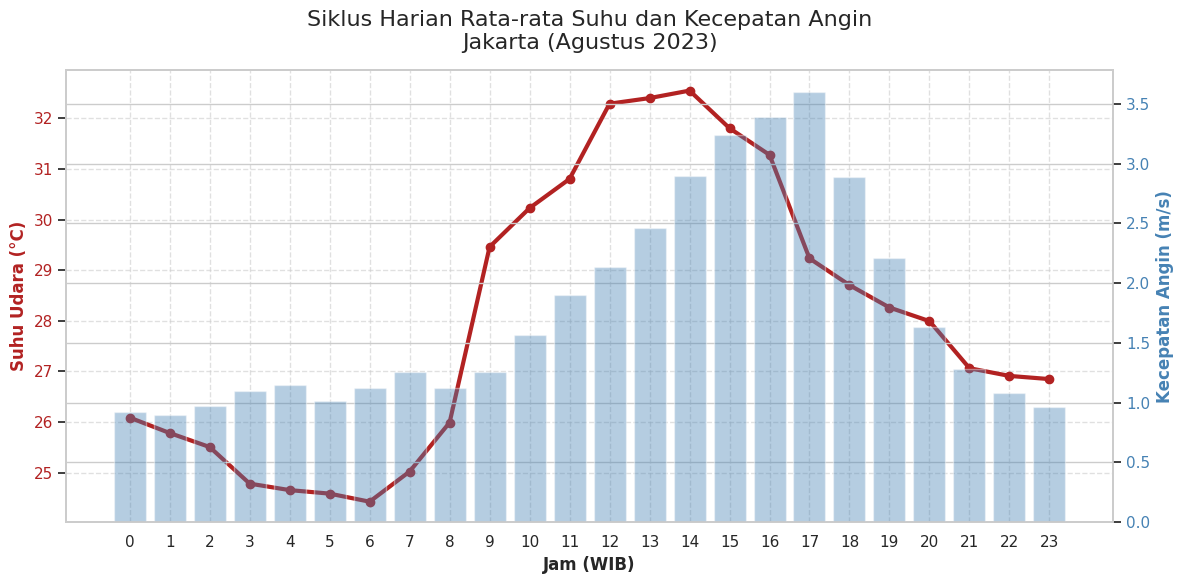

--- Kesimpulan Analisis ---
1. Suhu terdingin rata-rata terjadi pada pukul 06:00 WIB.
2. Suhu terpanas rata-rata terjadi pada pukul 14:00 WIB.


In [6]:
# 1. Kelompokkan data berdasarkan jam (0-23) dan cari nilai rata-ratanya
siklus_harian = df.groupby('jam')[['suhu_c', 'kecepatan_angin_ms']].mean().reset_index()

# 2. Pengaturan Gaya Grafik
sns.set_theme(style="whitegrid")
fig, ax1 = plt.subplots(figsize=(12, 6))

# 3. Plot Suhu Udara (Sumbu Y kiri)
warna_suhu = 'firebrick'
ax1.set_xlabel('Jam (WIB)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Suhu Udara (°C)', color=warna_suhu, fontsize=12, fontweight='bold')
ax1.plot(siklus_harian['jam'], siklus_harian['suhu_c'], color=warna_suhu, linewidth=3, marker='o', label='Suhu (°C)')
ax1.tick_params(axis='y', labelcolor=warna_suhu)
ax1.set_xticks(range(0, 24))

# 4. Buat Sumbu Y kanan untuk Kecepatan Angin (berbagi sumbu X yang sama)
ax2 = ax1.twinx()
warna_angin = 'steelblue'
ax2.set_ylabel('Kecepatan Angin (m/s)', color=warna_angin, fontsize=12, fontweight='bold')
ax2.bar(siklus_harian['jam'], siklus_harian['kecepatan_angin_ms'], color=warna_angin, alpha=0.4, label='Kecepatan Angin')
ax2.tick_params(axis='y', labelcolor=warna_angin)

# 5. Tambahkan Judul dan Grid
plt.title('Siklus Harian Rata-rata Suhu dan Kecepatan Angin\nJakarta (Agustus 2023)', fontsize=16, pad=15)
ax1.grid(True, linestyle='--', alpha=0.6)

# Tampilkan grafik
fig.tight_layout()
plt.show()

# 6. Analisis Singkat Terprogram
jam_suhu_max = siklus_harian.loc[siklus_harian['suhu_c'].idxmax(), 'jam']
jam_suhu_min = siklus_harian.loc[siklus_harian['suhu_c'].idxmin(), 'jam']

print(f"--- Kesimpulan Analisis ---")
print(f"1. Suhu terdingin rata-rata terjadi pada pukul {int(jam_suhu_min):02d}:00 WIB.")
print(f"2. Suhu terpanas rata-rata terjadi pada pukul {int(jam_suhu_max):02d}:00 WIB.")

# 5. Menarik Data untuk Dua Bulan Berbeda

Kita akan membuat fungsi ekstraksi agar kode lebih rapi, lalu memanggil fungsi tersebut untuk bulan Januari (Musim Hujan) dan Agustus (Musim Kemarau).

In [7]:
import ee
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Tentukan Lokasi (Monas, Jakarta)
lokasi = ee.Geometry.Point([106.8272, -6.1754])

# 2. Fungsi untuk mengambil koleksi data dan mengekstrak nilainya
def ambil_data_era5(tanggal_mulai, tanggal_akhir):
    # Filter dataset berdasarkan waktu dan pilih suhu
    # Catatan: tanggal_akhir di GEE bersifat eksklusif (tidak termasuk)
    era5 = ee.ImageCollection('ECMWF/ERA5/HOURLY') \
        .filterDate(tanggal_mulai, tanggal_akhir) \
        .select('temperature_2m')

    # Fungsi ekstraksi piksel
    def ekstrak_titik(image):
        nilai = image.reduceRegion(
            reducer=ee.Reducer.first(),
            geometry=lokasi,
            scale=27830
        )
        return ee.Feature(None, {
            'waktu': image.get('system:time_start'),
            'suhu_k': nilai.get('temperature_2m')
        })

    # Terapkan fungsi dan unduh data
    return era5.map(ekstrak_titik).getInfo()['features']

# 3. Proses pengunduhan data (Mungkin butuh waktu 10-20 detik)
print("Mengunduh data Januari 2023...")
# Gunakan '2023-02-01' sebagai batas akhir agar data 31 Januari ikut terambil
data_januari = ambil_data_era5('2023-01-01', '2023-02-01')

print("Mengunduh data Agustus 2023...")
# Gunakan '2023-09-01' sebagai batas akhir agar data 31 Agustus ikut terambil
data_agustus = ambil_data_era5('2023-08-01', '2023-09-01')

print("Selesai mengunduh!")

Mengunduh data Januari 2023...
Mengunduh data Agustus 2023...
Selesai mengunduh!


# 6. Pemrosesan Data dan Penggabungan

Sekarang kita ubah kedua data JSON tersebut menjadi DataFrame Pandas, melakukan konversi suhu, dan menggabungkannya.

In [8]:
# Fungsi untuk mengubah JSON ke DataFrame yang sudah dikonversi
def proses_ke_dataframe(data_mentah, nama_bulan):
    baris_data = []
    for fitur in data_mentah:
        prop = fitur['properties']
        if prop['suhu_k'] is not None:
            baris_data.append({
                'waktu_utc': pd.to_datetime(prop['waktu'], unit='ms'),
                'suhu_c': prop['suhu_k'] - 273.15,
                'bulan': nama_bulan # Menambahkan label bulan
            })

    df = pd.DataFrame(baris_data)
    # Konversi ke WIB dan ekstrak jam
    df['waktu_wib'] = df['waktu_utc'] + pd.Timedelta(hours=7)
    df['jam'] = df['waktu_wib'].dt.hour
    return df

# Proses masing-masing data
df_jan = proses_ke_dataframe(data_januari, 'Januari (Musim Hujan)')
df_agu = proses_ke_dataframe(data_agustus, 'Agustus (Musim Kemarau)')

# Gabungkan kedua DataFrame menjadi satu tabel panjang
df_gabungan = pd.concat([df_jan, df_agu], ignore_index=True)

# Hitung rata-rata suhu harian berdasarkan 'bulan' dan 'jam'
siklus_komparasi = df_gabungan.groupby(['bulan', 'jam'])['suhu_c'].mean().reset_index()

print("Sampel Data yang siap diplot:")
display(siklus_komparasi.head(100))

Sampel Data yang siap diplot:


,bulan,jam,suhu_c
0,Agustus (Musim Kemarau),0,26.058279
1,Agustus (Musim Kemarau),1,25.751557
2,Agustus (Musim Kemarau),2,25.479100
3,Agustus (Musim Kemarau),3,24.753156
4,Agustus (Musim Kemarau),4,24.620997
5,Agustus (Musim Kemarau),5,24.540509
6,Agustus (Musim Kemarau),6,24.379731
7,Agustus (Musim Kemarau),7,24.993263
8,Agustus (Musim Kemarau),8,25.963609
9,Agustus (Musim Kemarau),9,29.465506


In [9]:
data_mentah

[{'type': 'Feature',
  'geometry': None,
  'id': '20230801T00',
  'properties': {'suhu_k': 297.243408203125,
   'u_wind': -0.5395946502685547,
   'v_wind': 1.559678554534912,
   'waktu': 1690848000000}},
 {'type': 'Feature',
  'geometry': None,
  'id': '20230801T01',
  'properties': {'suhu_k': 298.7091979980469,
   'u_wind': -1.194068431854248,
   'v_wind': 1.113654375076294,
   'waktu': 1690851600000}},
 {'type': 'Feature',
  'geometry': None,
  'id': '20230801T02',
  'properties': {'suhu_k': 303.25067138671875,
   'u_wind': -2.9272079467773438,
   'v_wind': 0.7025018930435181,
   'waktu': 1690855200000}},
 {'type': 'Feature',
  'geometry': None,
  'id': '20230801T03',
  'properties': {'suhu_k': 304.00018310546875,
   'u_wind': -4.340703010559082,
   'v_wind': 0.17909979820251465,
   'waktu': 1690858800000}},
 {'type': 'Feature',
  'geometry': None,
  'id': '20230801T04',
  'properties': {'suhu_k': 304.68292236328125,
   'u_wind': -4.6518449783325195,
   'v_wind': -0.3124384880065918,

In [10]:
!pip install itables
from itables import show
show(df_gabungan)

# 7. Visualisasi Perbandingan dengan Seaborn

Library seaborn (sns) sangat memudahkan kita membuat plot dengan pengelompokan menggunakan parameter hue.

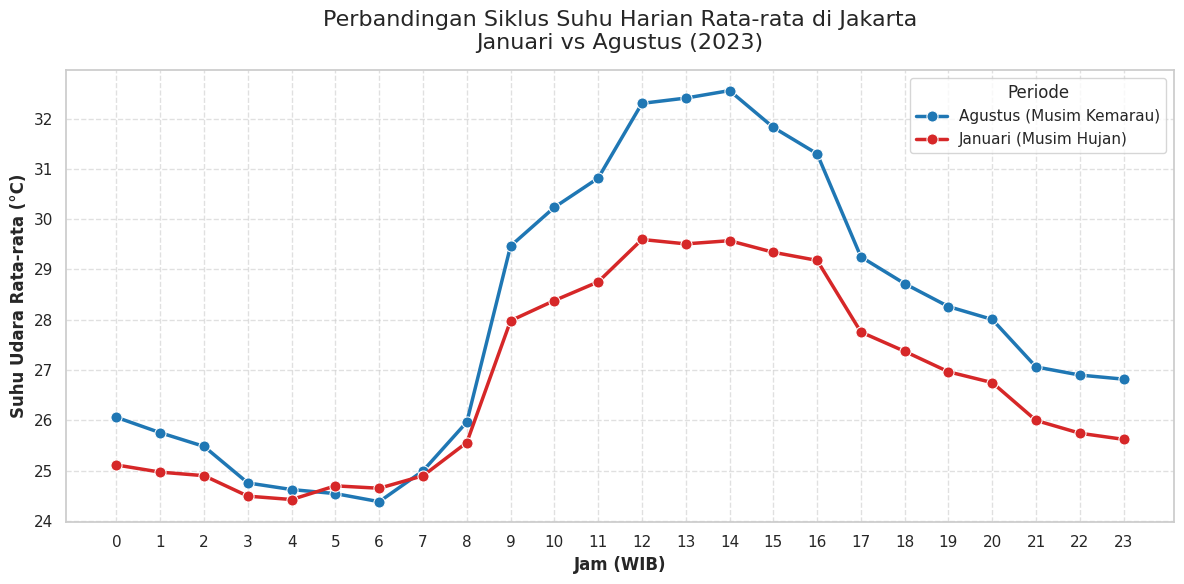

In [11]:
# Pengaturan Gaya Grafik
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

# Plot menggunakan Seaborn
# 'hue' akan otomatis memisahkan garis dan memberi warna berbeda berdasarkan kolom 'bulan'
sns.lineplot(
    data=siklus_komparasi,
    x='jam',
    y='suhu_c',
    hue='bulan',
    palette=['#1f77b4', '#d62728'], # Biru untuk Jan, Merah untuk Agu
    marker='o',
    linewidth=2.5,
    markersize=8
)

# Kustomisasi Tampilan
plt.title('Perbandingan Siklus Suhu Harian Rata-rata di Jakarta\nJanuari vs Agustus (2023)', fontsize=16, pad=15)
plt.xlabel('Jam (WIB)', fontsize=12, fontweight='bold')
plt.ylabel('Suhu Udara Rata-rata (°C)', fontsize=12, fontweight='bold')
plt.xticks(range(0, 24)) # Memaksa sumbu X menampilkan semua jam 0-23
plt.legend(title='Periode', title_fontsize='12', fontsize='11')
plt.grid(True, linestyle='--', alpha=0.6)

# Tampilkan grafik
plt.tight_layout()
plt.show()

# Visualisasi Spasial Image Statis


/usr/local/lib/python3.13/dist-packages/ee/deprecation.py:215: DeprecationWarning: 

Attention required for FAO/GAUL/2015/level1! You are using a deprecated asset.
To make sure your code keeps working, please update it.
This dataset has been superseded by FAO/GAUL/2025/level1

Learn more: https://developers.google.com/earth-engine/datasets/catalog/FAO_GAUL_2015_level1

  warnings.warn(warning, category=DeprecationWarning)


Sedang merender gambar dari server Earth Engine...


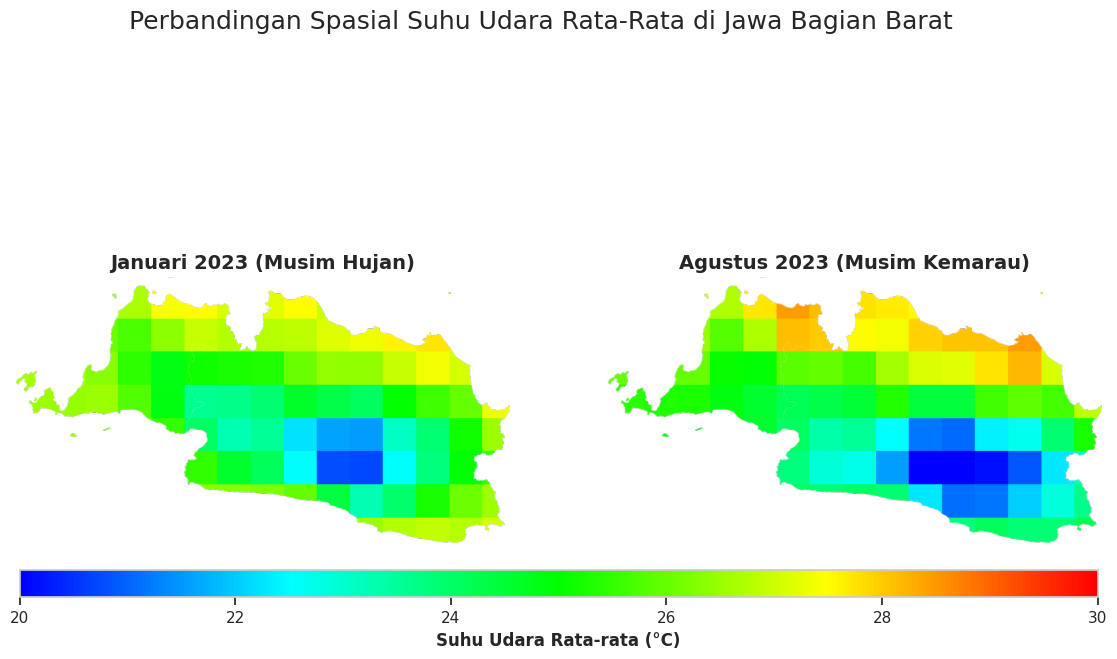

In [12]:
import ee
import urllib.request
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm
from PIL import Image

# Pastikan Anda sudah menjalankan ee.Authenticate() sebelumnya
ee.Initialize(project='your-project-id')

# 1. AMBIL BATAS WILAYAH (Jakarta, Banten, Jawa Barat)
provinsi = ['Jakarta Raya', 'Jawa Barat', 'Banten']
batas_wilayah = ee.FeatureCollection("FAO/GAUL/2015/level1") \
    .filter(ee.Filter.inList('ADM1_NAME', provinsi))

# 2. FUNGSI EKSTRAKSI SUHU RATA-RATA BULANAN
def ambil_suhu_statis(tanggal_mulai, tanggal_akhir):
    dataset = ee.ImageCollection('ECMWF/ERA5/HOURLY') \
        .filterDate(tanggal_mulai, tanggal_akhir) \
        .select('temperature_2m') \
        .mean()
    # Konversi ke Celcius dan clip sesuai batas 3 provinsi
    return dataset.subtract(273.15).clip(batas_wilayah)

suhu_januari = ambil_suhu_statis('2023-01-01', '2023-02-01')
suhu_agustus = ambil_suhu_statis('2023-08-01', '2023-09-01')

# 3. PENGATURAN VISUALISASI DAN GENERATE LINK GAMBAR
# Karena ini mencakup pegunungan (Jawa Barat) dan pesisir (Jakarta),
# kita gunakan rentang suhu 20°C hingga 30°C
vis_params = {
    'min': 20.0,
    'max': 30.0,
    'palette': ['#0000ff', '#00ffff', '#00ff00', '#ffff00', '#ff0000'],
    'region': batas_wilayah.geometry().bounds(), # Bounding box untuk area gambar
    'dimensions': 800, # Resolusi lebar gambar output (piksel)
    'format': 'png'
}

print("Sedang merender gambar dari server Earth Engine...")
url_jan = suhu_januari.getThumbURL(vis_params)
url_agu = suhu_agustus.getThumbURL(vis_params)

# Unduh gambar PNG dari URL ke memori Python
img_jan = Image.open(urllib.request.urlopen(url_jan))
img_agu = Image.open(urllib.request.urlopen(url_agu))

# 4. PLOTTING STATIS DENGAN MATPLOTLIB
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

# Plot Januari (Kiri)
axes[0].imshow(img_jan)
axes[0].set_title('Januari 2023 (Musim Hujan)', fontsize=14, fontweight='bold')
axes[0].axis('off') # Hilangkan sumbu X/Y karena berupa gambar PNG murni

# Plot Agustus (Kanan)
axes[1].imshow(img_agu)
axes[1].set_title('Agustus 2023 (Musim Kemarau)', fontsize=14, fontweight='bold')
axes[1].axis('off')

# 5. MEMBUAT COLORBAR (LEGENDA WARNA) DI BAWAH GAMBAR
# Kita membuat 'dummy' pemetaan warna khusus untuk legenda Matplotlib
# agar sesuai dengan vis_params dari Earth Engine
cmap = mcolors.LinearSegmentedColormap.from_list('era5_cmap', vis_params['palette'])
norm = mcolors.Normalize(vmin=vis_params['min'], vmax=vis_params['max'])
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

# Tempelkan colorbar di bawah kedua grafik
cbar = fig.colorbar(sm, ax=axes.ravel().tolist(), orientation='horizontal', fraction=0.05, pad=0.05, aspect=40)
cbar.set_label('Suhu Udara Rata-rata (°C)', fontsize=12, fontweight='bold')

plt.suptitle('Perbandingan Spasial Suhu Udara Rata-Rata di Jawa Bagian Barat', fontsize=18, y=0.95)
plt.show()

# Visualisasi Peta Interaktif

In [13]:
# Instalasi geemap (Hanya perlu dijalankan sekali)
# !pip install geemap --quiet

import ee
import geemap

# Inisialisasi GEE menggunakan Project ID Anda yang valid
ee.Initialize(project='your-project-id')

# 1. MENDAPATKAN BATAS WILAYAH JAKARTA
# Menggunakan dataset batas provinsi (level 1) sedunia dari FAO, difilter khusus Jakarta
batas_jakarta = ee.FeatureCollection("FAO/GAUL/2015/level1").filter(ee.Filter.eq('ADM1_NAME', 'Jakarta Raya'))

# 2. PANGGIL DATA, HITUNG RATA-RATA, KONVERSI SUHU, DAN CLIP
era5_agustus = ee.ImageCollection('ECMWF/ERA5/HOURLY') \
    .filterDate('2023-08-01', '2023-09-01') \
    .select('temperature_2m') \
    .mean()

# Kurangi 273.15 untuk Celcius, lalu CLIP sesuai batas Polygon Jakarta
suhu_c = era5_agustus.subtract(273.15).clip(batas_jakarta)

# 3. PENGATURAN VISUALISASI
# Catatan: Nilai min-max saya ubah menjadi 26-32. Karena ukuran Jakarta kecil,
# jika rentangnya 20-35 warnanya akan terlihat sama semua (monoton).
vis_params = {
    'min': 26.0,
    'max': 32.0,
    'palette': ['#0000ff', '#00ffff', '#00ff00', '#ffff00', '#ff0000']
}

# 4. MEMBUAT KANVAS PETA
peta = geemap.Map()

# 5. MENAMBAHKAN BASEMAP OPENTOPOMAP
url_opentopo = 'https://{s}.tile.opentopomap.org/{z}/{x}/{y}.png'
atribusi_opentopo = 'Map data: © OpenStreetMap contributors, SRTM | Map style: © OpenTopoMap (CC-BY-SA)'

peta.add_tile_layer(url=url_opentopo, name='OpenTopoMap', attribution=atribusi_opentopo)

# 6. TAMBAHKAN LAYER RASTER DAN GARIS BATAS
# Tambahkan hasil clip suhu
peta.addLayer(suhu_c, vis_params, 'Suhu Udara Jakarta Agustus 2023')

# (Opsional) Tambahkan garis batas/outline provinsi dengan warna hitam agar lebih rapi
outline = ee.Image().paint(batas_jakarta, 0, 2) # Angka 2 adalah ketebalan garis
peta.addLayer(outline, {'palette': 'black'}, 'Batas Jakarta')

# 7. PUSATKAN PETA OTOMATIS KE JAKARTA
# Menggunakan set_center koordinat Jakarta sebagai fallback aman agar tidak terjadi error jika objek batas kosong
peta.set_center(106.8272, -6.1754, 10)

# 8. TAMBAHKAN COLORBAR
peta.add_colorbar(vis_params, label='Suhu Udara (°C)', orientation='vertical')

# Tampilkan Peta
peta

Map(center=[-6.1754, 106.8272], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topr…